In [8]:
import pandas as pd
from prophet import Prophet

df = pd.read_csv('../data/tickers/WEB.AX.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-12-01 00:00:00+11:00,5.37,5.380,5.26,5.32,2889215,0.0,0.0
1,2021-12-02 00:00:00+11:00,5.20,5.335,5.15,5.32,2562479,0.0,0.0
2,2021-12-03 00:00:00+11:00,5.46,5.460,5.30,5.40,2817363,0.0,0.0
3,2021-12-06 00:00:00+11:00,5.36,5.480,5.30,5.32,2260633,0.0,0.0
4,2021-12-07 00:00:00+11:00,5.50,5.570,5.45,5.56,2599927,0.0,0.0


In [9]:
simple_df = pd.DataFrame()
simple_df['ds'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
simple_df['y'] = df['Close']

In [10]:
m = Prophet()
m.fit(simple_df)

21:44:26 - cmdstanpy - INFO - Chain [1] start processing
21:44:26 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
future = m.make_future_dataframe(periods=28)
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2021-11-30 13:00:00,5.501267,5.269509,5.731661
1,2021-12-01 13:00:00,5.475703,5.229887,5.700268
2,2021-12-02 13:00:00,5.477644,5.246176,5.697905
3,2021-12-05 13:00:00,5.414671,5.206267,5.656976
4,2021-12-06 13:00:00,5.407809,5.174797,5.634322
...,...,...,...,...
529,2023-12-24 13:00:00,6.438581,6.223239,6.686628
530,2023-12-25 13:00:00,6.455613,6.217421,6.691469
531,2023-12-26 13:00:00,6.493595,6.274163,6.709109
532,2023-12-27 13:00:00,6.477297,6.245602,6.701748


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


(array(19554.58333333), 19720.905864747452)

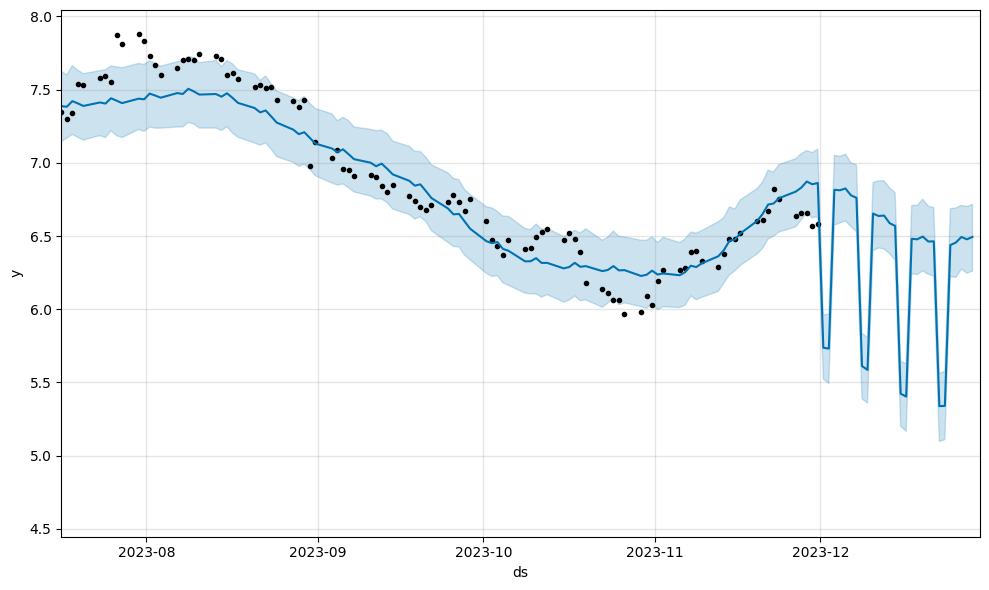

In [12]:
fig1 = m.plot(forecast)
ax = fig1.gca()

ax.set_xlim(simple_df['ds'].take([-100]), pd.to_datetime('now') + pd.DateOffset(days=28))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will

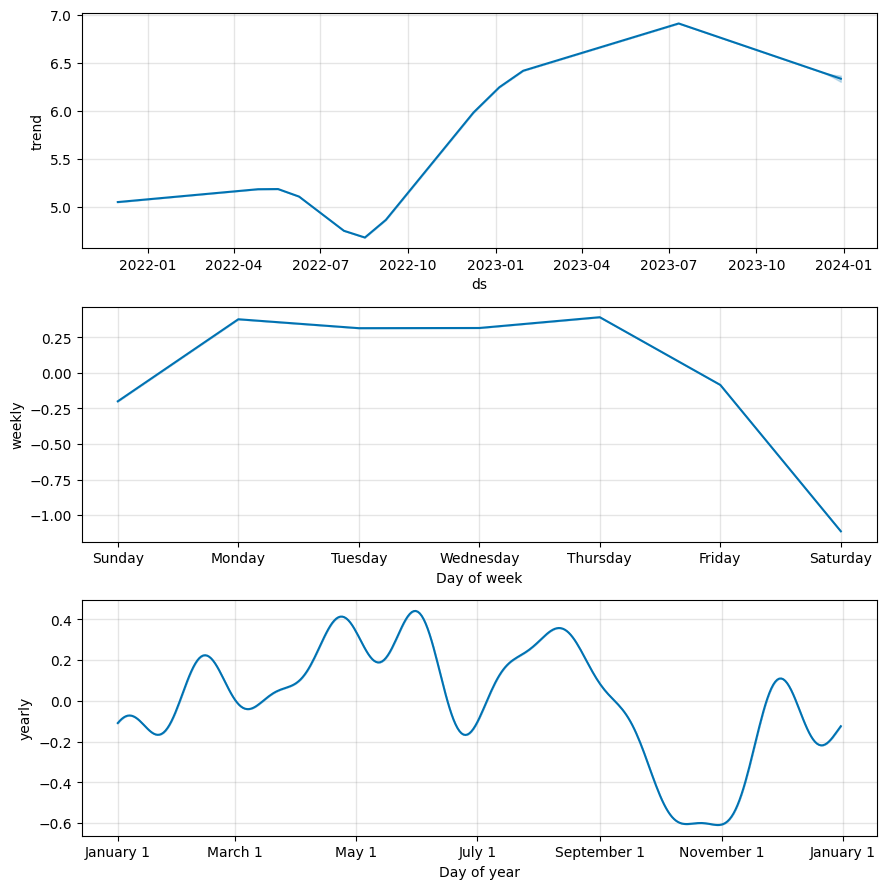

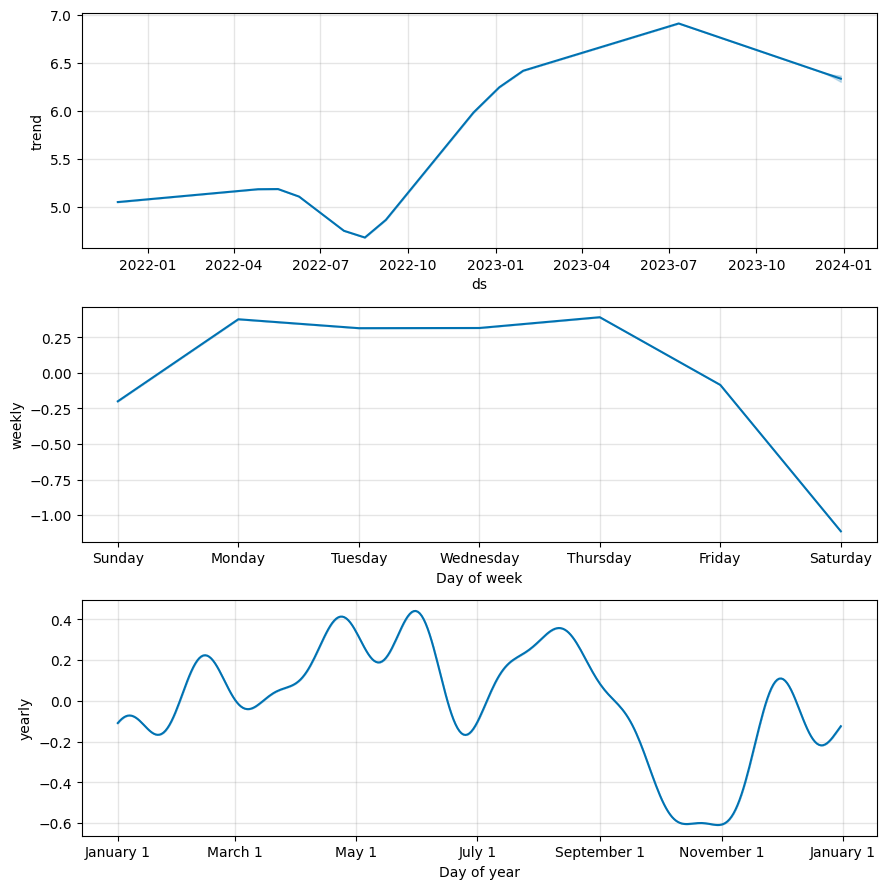

In [13]:
m.plot_components(forecast)